[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/renatslarg/machine-learning-comparision-of-classification-models/blob/main/ML_Modelos_de_Clasificacion_Comparacion.ipynb)

![Image in a markdown cell](https://cursos.utnba.centrodeelearning.com/pluginfile.php/1/theme_space/customlogo/1738330016/Logo%20UTN%20Horizontal.png)



# **Diplomado de Ciencia de Datos y Análisis Avanzado**
# **Modelado Predictivo**: Clasificación

# **Proyecto de Competencia Kaggle: Predicción de Abandono de Clientes**

# **Autor:**
### *   **Ing. César Renato Ramírez**

# **Objetivo:**
## El objetivo de este proyecto es construir y evaluar varios modelos de clasificación para predecir si un cliente de una compañía de telecomunicaciones abandonará o no el servicio (churn). El rendimiento final del mejor modelo se medirá a través de la **métrica ROC AUC**.


# **Enlace para unirse a la competencia**
### **USE EL ENLACE PARA UNIRSE POR EQUIPO, NO DE MANERA INDIVIDUAL**

https://www.kaggle.com/t/57b70c381e4d451b8ae38e164b91a2aa


### **Por favor siga las indicaciones que se suministran en la plataforma**


# 0. **Configuración Inicial e Importación de Librerías**

## En esta sección, se importan todas las librerías necesarias para el proyecto. Es una buena práctica tener todas las importaciones en la primera celda.


In [66]:
# Para manipulación de datos
import pandas as pd
import numpy as np

# Para visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Para preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_classif

# Para modelado
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Para evaluación
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, f1_score, auc
from sklearn.model_selection import cross_val_score
# Configuraciones adicionales para una mejor visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
# Ignorar warnings para una salida más limpia (opcional)
import warnings
warnings.filterwarnings('ignore')

#  **1. Carga de Datos**

## Se cargan los datasets proporcionados para la competencia: `train.csv`, `test.csv` y `sample_submission.csv`.


In [67]:
try:
    train_df = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')
    sample_submission_df = pd.read_csv('sample_submission.csv')
except FileNotFoundError:
    print("Asegúrate de que los archivos .csv de la competencia estén en el mismo directorio que este cuaderno.")
    # Si usas Colab, puedes subir los archivos al entorno de ejecución.
    exit()

print("Forma del dataset de entrenamiento:", train_df.shape)
print("Forma del dataset de prueba:", test_df.shape)

print("\nPrimeras 5 filas del dataset de entrenamiento:")
display(train_df.head())

print("\nPrimeras 5 filas del dataset de prueba:")
display(test_df.head())

Forma del dataset de entrenamiento: (5634, 21)
Forma del dataset de prueba: (1409, 20)

Primeras 5 filas del dataset de entrenamiento:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4950-BDEUX,Male,0,No,No,35,No,No phone service,DSL,No,...,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,49.20,1701.65,No
1,7993-NQLJE,Male,0,Yes,Yes,15,Yes,No,Fiber optic,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,75.10,1151.55,No
2,7321-ZNSLA,Male,0,Yes,Yes,13,No,No phone service,DSL,Yes,...,No,Yes,No,No,Two year,No,Mailed check,40.55,590.35,No
3,4922-CVPDX,Female,0,Yes,No,26,Yes,No,DSL,No,...,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),73.50,1905.70,No
4,2903-YYTBW,Male,0,Yes,Yes,1,Yes,No,DSL,No,...,No,No,No,No,Month-to-month,No,Electronic check,44.55,44.55,No



Primeras 5 filas del dataset de prueba:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,4376-KFVRS,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.20
1,2754-SDJRD,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55
2,9917-KWRBE,Female,0,Yes,Yes,41,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,No,One year,Yes,Credit card (automatic),78.35,3211.20
3,0365-GXEZS,Male,0,Yes,No,18,Yes,No,Fiber optic,No,No,Yes,Yes,No,No,Month-to-month,No,Electronic check,78.20,1468.75
4,9385-NXKDA,Female,0,Yes,No,72,Yes,Yes,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Credit card (automatic),82.65,5919.35


# **2. Análisis Exploratorio de Datos (EDA)**

## En esta fase, se explora el dataset de entrenamiento para entender mejor los datos, encontrar patrones, identificar valores faltantes y visualizar relaciones entre las características y la variable objetivo (`Churn`).


In [68]:
train_df.info() # Ver tipo de datos y valores de cada columna (campos) del dataset de entrenamiento.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        5634 non-null   object 
 1   gender            5634 non-null   object 
 2   SeniorCitizen     5634 non-null   int64  
 3   Partner           5634 non-null   object 
 4   Dependents        5634 non-null   object 
 5   tenure            5634 non-null   int64  
 6   PhoneService      5634 non-null   object 
 7   MultipleLines     5634 non-null   object 
 8   InternetService   5634 non-null   object 
 9   OnlineSecurity    5634 non-null   object 
 10  OnlineBackup      5634 non-null   object 
 11  DeviceProtection  5634 non-null   object 
 12  TechSupport       5634 non-null   object 
 13  StreamingTV       5634 non-null   object 
 14  StreamingMovies   5634 non-null   object 
 15  Contract          5634 non-null   object 
 16  PaperlessBilling  5634 non-null   object 


**Se observan variables tipo: numérico entero (int64), numérico decimal (float64) y categóricas (object) . A continuación procederemos a mostrar las diferentes variables con los valores que pueden contener.**

In [69]:
object_columns = train_df.select_dtypes(include=['object']) #Para variables categóricas.
object_columns.columns
for column in object_columns.columns:
    print(f"Columna:{column}")
    print(train_df[column].value_counts())
    print("\n")

Columna:customerID
customerID
6490-FGZAT    1
4950-BDEUX    1
4194-FJARJ    1
8207-DMRVL    1
2154-KVJFF    1
             ..
8562-GHPPI    1
8414-OOEEL    1
2903-YYTBW    1
4922-CVPDX    1
7321-ZNSLA    1
Name: count, Length: 5634, dtype: int64


Columna:gender
gender
Male      2833
Female    2801
Name: count, dtype: int64


Columna:Partner
Partner
No     2905
Yes    2729
Name: count, dtype: int64


Columna:Dependents
Dependents
No     3955
Yes    1679
Name: count, dtype: int64


Columna:PhoneService
PhoneService
Yes    5075
No      559
Name: count, dtype: int64


Columna:MultipleLines
MultipleLines
No                  2685
Yes                 2390
No phone service     559
Name: count, dtype: int64


Columna:InternetService
InternetService
Fiber optic    2483
DSL            1937
No             1214
Name: count, dtype: int64


Columna:OnlineSecurity
OnlineSecurity
No                     2797
Yes                    1623
No internet service    1214
Name: count, dtype: int64


Columna:Onl

In [70]:
object_columns1 = train_df.select_dtypes(include=['int64']) #Para variables numéricas.
object_columns1.columns
for column in object_columns1.columns:
    print(f"Columna:{column}")
    print(train_df[column].value_counts())
    print("\n")

Columna:SeniorCitizen
SeniorCitizen
0    4714
1     920
Name: count, dtype: int64


Columna:tenure
tenure
1     487
72    292
2     187
3     150
71    142
     ... 
21     45
44     43
28     42
36     40
0       8
Name: count, Length: 73, dtype: int64




In [71]:
object_columns2 = train_df.select_dtypes(include=['float64']) #Para variables numéricas con decimales.
object_columns2.columns
for column in object_columns2.columns:
    print(f"Columna:{column}")
    print(train_df[column].value_counts())
    print("\n")

Columna:MonthlyCharges
MonthlyCharges
20.05     50
19.65     37
20.00     37
20.15     36
19.85     36
          ..
112.75     1
23.90      1
80.95      1
103.50     1
108.80     1
Name: count, Length: 1489, dtype: int64


Columna:TotalCharges
TotalCharges
20.200      9
1397.475    8
19.650      7
45.300      7
19.900      6
           ..
80.350      1
2660.200    1
109.300     1
1761.450    1
232.550     1
Name: count, Length: 5276, dtype: int64




**Exploración estadística de variables numéricas**

In [72]:
train_df.describe() # estadisticas de las variables numericas

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.163294,32.485091,64.929961,2301.319027
std,0.369667,24.568744,30.138105,2277.809211
min,0.000000,0.000000,18.400000,18.850000
25%,0.000000,9.000000,35.662500,408.850000
50%,0.000000,29.000000,70.500000,1397.475000
75%,0.000000,55.000000,90.000000,3835.825000
max,1.000000,72.000000,118.750000,8684.800000


**Gráficos de Histograma Variables numéricas.**

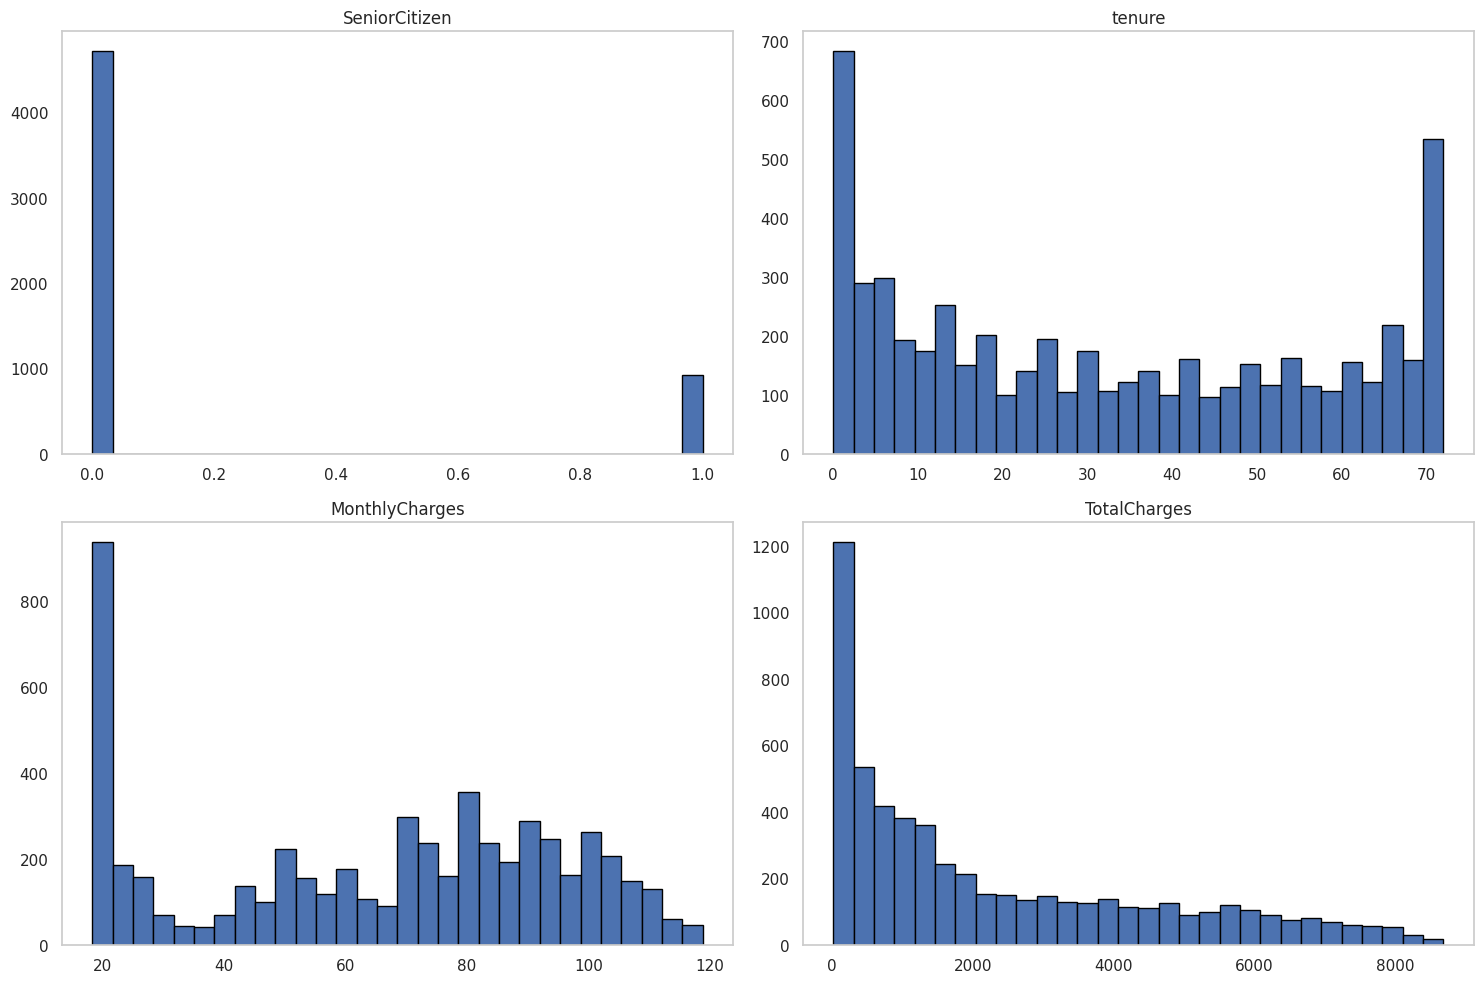

In [73]:
train_df.hist(figsize=(15, 10), bins=30, edgecolor='black', grid=False)
plt.tight_layout()
plt.show()

Las variables analizadas no siguen una distribución normal.

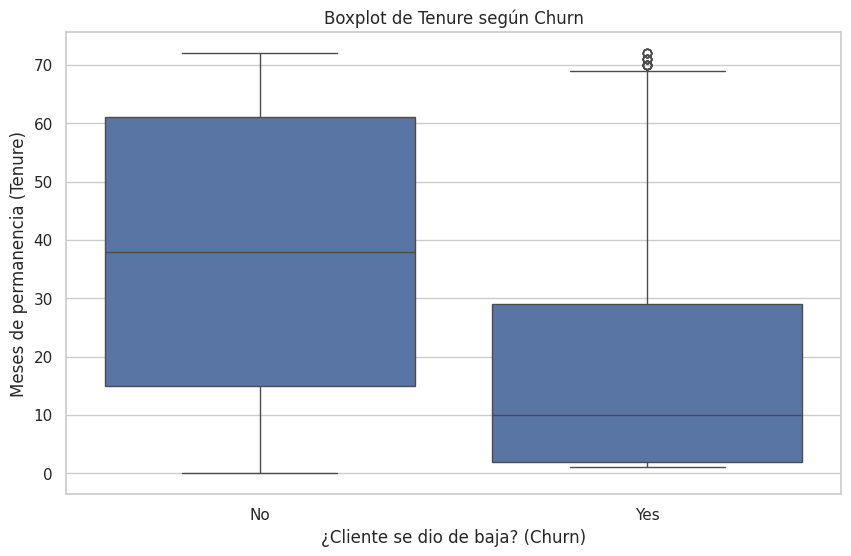

In [74]:
plt.figure(figsize=(10, 6))  # Tamaño del gráfico

# Boxplot para comparar la distribución del tiempo de permanencia (tenure) según el churn
sns.boxplot(x='Churn', y='tenure', data=train_df)

# Títulos y etiquetas
plt.title('Boxplot de Tenure según Churn')
plt.xlabel('¿Cliente se dio de baja? (Churn)')
plt.ylabel('Meses de permanencia (Tenure)')

# Mostrar el gráfico
plt.show()

In [75]:
# ====================================================================
#Detección de outliers por grupo (por categoría de Churn)
# ====================================================================

# Iterar sobre cada categoría única de la variable Churn
for categoria in train_df['Churn'].unique():
    # Crear un subconjunto del DataFrame para la categoría actual
    subset = train_df[train_df['Churn'] == categoria].copy()

    # Calcular Q1, Q3 y el IQR para la columna 'tenure' en el subconjunto
    Q1 = subset['tenure'].quantile(0.25)
    Q3 = subset['tenure'].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites para los outliers
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar los outliers en el subconjunto
    outliers_en_subset = subset[(subset['tenure'] < limite_inferior) | (subset['tenure'] > limite_superior)]

    # Imprimir los resultados para cada categoría
    print(f"\n=============================================================")
    print(f"🔍 Outliers en 'tenure' para el grupo Churn = {categoria}")
    print(f"=============================================================")
    if not outliers_en_subset.empty:
        print(outliers_en_subset[['Churn', 'tenure']])
    else:
        print("No se encontraron outliers para este grupo.")


🔍 Outliers en 'tenure' para el grupo Churn = No
No se encontraron outliers para este grupo.

🔍 Outliers en 'tenure' para el grupo Churn = Yes
     Churn  tenure
636    Yes      71
658    Yes      70
966    Yes      70
993    Yes      72
1398   Yes      72
1417   Yes      70
1810   Yes      71
1882   Yes      70
1890   Yes      71
2383   Yes      71
3318   Yes      70
3341   Yes      70
3371   Yes      70
3704   Yes      70
3889   Yes      70
4019   Yes      72
4204   Yes      72
4621   Yes      71
5270   Yes      71
5550   Yes      72


Caja de la izquierda (Churn = No):
La mediana está alrededor de 38-40. El 50% central de los datos se encuentra aproximadamente entre 15 y 60.
Los bigotes se extienden hasta los valores máximo y mínimo del grupo, sin mostrar puntos individuales fuera de ellos.
Por lo tanto, para los clientes que se quedaron, la distribución de tenure es bastante amplia y no hay valores atípicos según la regla del boxplot.

Caja de la derecha (Churn = Sí):
La mediana está en un valor mucho más bajo, alrededor de 10.
El 50% central de los datos está aproximadamente entre 5 y 28.
El bigote superior se extiende hasta casi 70.
Entonces, la mayoría de los clientes que abandonaron, tienen una permanencia mucho más corta que los que se quedaron.

Con respecto a los outliers, estos representan a clientes que, a pesar de haber tenido una permanencia muy larga (un tenure de más de 65 meses), terminaron abandonando el servicio. Se podría investigar esas causas.

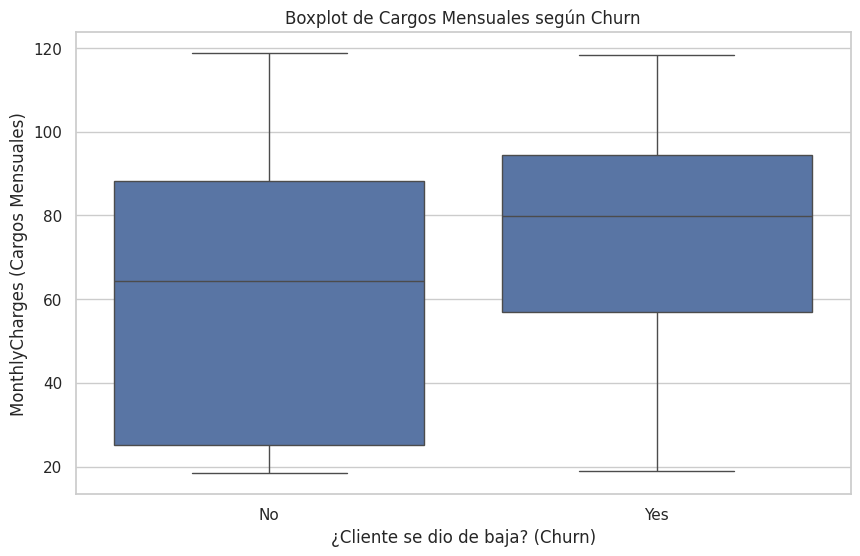

In [76]:
plt.figure(figsize=(10, 6))  # Tamaño del gráfico

# Boxplot para comparar la distribución de MonthlyCharges según el churn.
sns.boxplot(x='Churn', y='MonthlyCharges', data=train_df)

# Títulos y etiquetas
plt.title('Boxplot de Cargos Mensuales según Churn')
plt.xlabel('¿Cliente se dio de baja? (Churn)')
plt.ylabel('MonthlyCharges (Cargos Mensuales)')

# Mostrar el gráfico
plt.show()

Se detecta que existe una relación notable entre ambas. Las distribuciones de los cargos mensuales son visiblemente diferentes entre los dos grupos. La caja del grupo "Yes" está desplazada hacia arriba en comparación con la caja del grupo "No". Esto sugiere que, en promedio, los clientes que pagaban cargos mensuales más altos tenían más probabilidades de abandonar.
Este gráfico proporciona una fuerte evidencia de que MonthlyCharges es una variable predictora muy relevante para predecir el abandono. La diferencia en las medianas y en la distribución de los cargos mensuales entre los dos grupos es un indicador claro de que los clientes de alto gasto son un segmento que merece una atención especial, ya que son más propensos a abandonar el servicio.

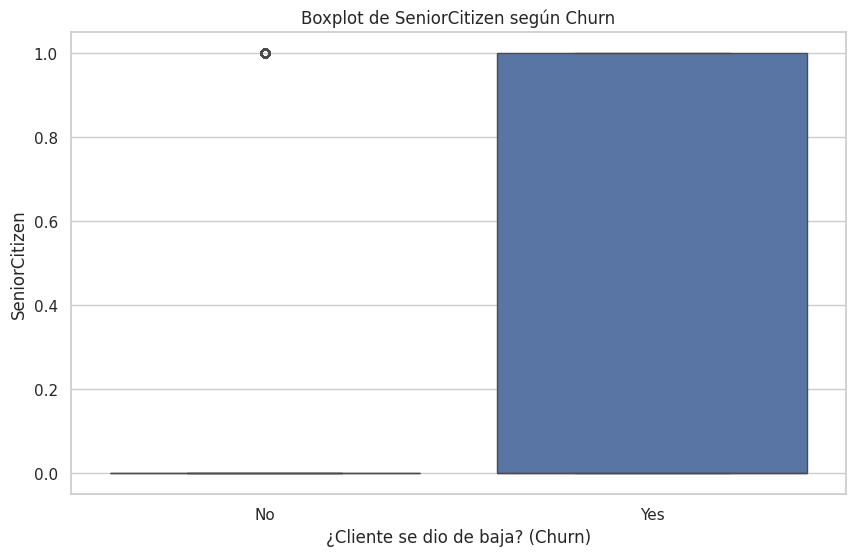

In [77]:
plt.figure(figsize=(10, 6))  # Tamaño del gráfico

# Boxplot para comparar la distribución de SeniorCitizen según el churn.
sns.boxplot(x='Churn', y='SeniorCitizen', data=train_df)

# Títulos y etiquetas
plt.title('Boxplot de SeniorCitizen según Churn')
plt.xlabel('¿Cliente se dio de baja? (Churn)')
plt.ylabel('SeniorCitizen')

# Mostrar el gráfico
plt.show()

La caja de la izquierda (Churn = No), está casi completamente aplanada en el valor 0. Esto indica que la inmensa mayoría de los clientes que no se dieron de baja, no son ciudadanos de la tercera edad.
En lo que respecta a outliers, existe un punto individual en el valor 1. Esto representa a los pocos clientes que son ciudadanos de la tercera edad y que se quedaron.
La caja de la derecha (Churn = Yes), se extiende desde 0 hasta 1, con la mediana y el 50% central de los datos ocupando la mayoría del espacio. Esto indica que la distribución de clientes que sí se dieron de baja (Churn = Yes) está mucho más balanceada entre los que son y no son ciudadanos de la tercera edad.
La diferencia entre los dos grupos es muy clara, el grupo de clientes que se quedaron (Churn = No) está compuesto casi exclusivamente por clientes que no son ciudadanos de la tercera edad. El grupo de clientes que se dieron de baja (Churn = Yes) tiene una proporción mucho mayor de ciudadanos de la tercera edad.
Esto proporciona una evidencia de que ser un ciudadano de la tercera edad es más propenso a abandonar.

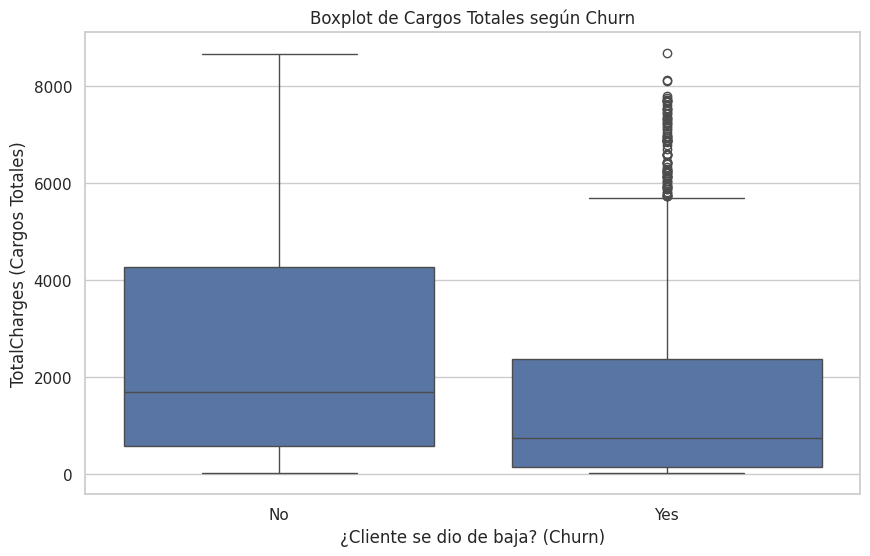

In [78]:
plt.figure(figsize=(10, 6))  # Tamaño del gráfico

# Boxplot para comparar la distribución de TotalCharges según el churn.
sns.boxplot(x='Churn', y='TotalCharges', data=train_df)

# Títulos y etiquetas
plt.title('Boxplot de Cargos Totales según Churn')
plt.xlabel('¿Cliente se dio de baja? (Churn)')
plt.ylabel('TotalCharges (Cargos Totales)')

# Mostrar el gráfico
plt.show()

In [79]:
# ====================================================================
#Detección de outliers por grupo (por categoría de Churn)
# ====================================================================

# Iterar sobre cada categoría única de la variable Churn
for categoria in train_df['Churn'].unique():
    # Crear un subconjunto del DataFrame para la categoría actual
    subset = train_df[train_df['Churn'] == categoria].copy()

    # Calcular Q1, Q3 y el IQR para la columna 'TotalCharges' en el subconjunto
    Q1 = subset['TotalCharges'].quantile(0.25)
    Q3 = subset['TotalCharges'].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites para los outliers
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Identificar los outliers en el subconjunto
    outliers_en_subset = subset[(subset['TotalCharges'] < limite_inferior) | (subset['TotalCharges'] > limite_superior)]

    # Imprimir los resultados para cada categoría
    print(f"\n=============================================================")
    print(f"🔍 Outliers en 'TotalCharges' para el grupo Churn = {categoria}")
    print(f"=============================================================")
    if not outliers_en_subset.empty:
        print(outliers_en_subset[['Churn', 'TotalCharges']])
    else:
        print("No se encontraron outliers para este grupo.")


🔍 Outliers en 'TotalCharges' para el grupo Churn = No
No se encontraron outliers para este grupo.

🔍 Outliers en 'TotalCharges' para el grupo Churn = Yes
     Churn  TotalCharges
127    Yes       6017.65
150    Yes       6143.15
213    Yes       7262.00
216    Yes       6127.60
272    Yes       5940.85
...    ...           ...
5385   Yes       6975.25
5397   Yes       6056.15
5534   Yes       6903.10
5550   Yes       8109.80
5620   Yes       6851.65

[84 rows x 2 columns]


En la caja de la izquierda (Churn = "No"), la mediana está en un valor relativamente bajo, alrededor de 1700. El 50% central de los clientes se encuentra aproximadamente entre 700 y 4200.
No se ven puntos individuales fuera de los bigotes, lo que indica que, visualmente, no hay outliers en este grupo.
En la caja de la derecha, (Churn = "Yes"), la mediana está en un valor mucho más bajo, alrededor de 800. El 50% central de los clientes se encuentra aproximadamente entre 400 y 2500.
Hay una gran cantidad de puntos individuales por encima del bigote superior, que son los outliers, y se extienden hasta valores superiores a 8000.
Aunque los clientes que se van (Churn = Yes) tienen un TotalCharges promedio y la mediana mucho más baja que los que se quedan, existe un grupo de clientes con cargos totales extremadamente altos que también se dieron de baja.

Entiendo que TotalCharges es una variable relevante para el Churn, pero su relación no está tan clara.

En general, los clientes con bajos cargos totales tienen una mayor propensión a irse. Esto es contrario a lo que vimos con MonthlyCharges y podría estar relacionado con la variable tenure (los clientes con baja permanencia tendrán bajos cargos totales, y ya vimos que la baja permanencia está ligada al abandono).
Pero existe un grupo de clientes de alto valor con cargos totales muy elevados que también se dieron de baja. Estos clientes (outliers) constituyen un grupo a investigar. Su abandono podría ser una señal de problemas graves con el servicio o la relación con el cliente.


**Exploración de variables categóricas**

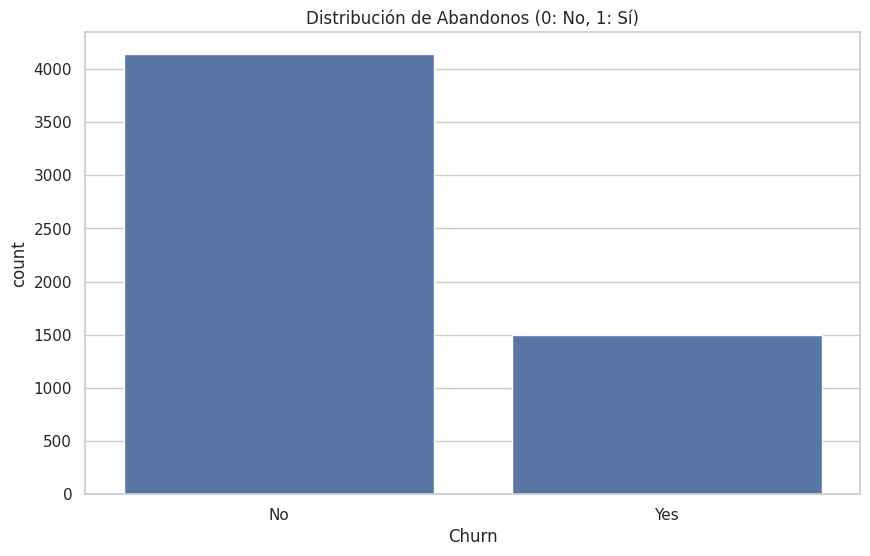


Proporción de Abandonos:
Churn
No     0.734647
Yes    0.265353
Name: proportion, dtype: float64


In [80]:
sns.countplot(x='Churn', data=train_df)
plt.title('Distribución de Abandonos (0: No, 1: Sí)')
plt.show()

print("\nProporción de Abandonos:")
print(train_df['Churn'].value_counts(normalize=True))

In [81]:
object_columns3 = train_df.select_dtypes(include=['object']) # Asigna todas las variables tipos "object"
object_columns3.columns # Lista las variables "object".

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

In [82]:
# Variables categóricas a analizar
categorical_vars = ['gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod']

# Iterar sobre cada variable categorica
for var in categorical_vars:
  # Crear una tabla de conteo
  cross_tab = pd.crosstab(train_df[var], train_df['Churn'], margins=True, margins_name='Total')

  # Mostrar la tabla de conteo
  print(f"Tabla de conteo para '{var.capitalize()}' vs 'Churn':")
  print(cross_tab)
  print("\n")

Tabla de conteo para 'Gender' vs 'Churn':
Churn     No   Yes  Total
gender                   
Female  2055   746   2801
Male    2084   749   2833
Total   4139  1495   5634


Tabla de conteo para 'Partner' vs 'Churn':
Churn      No   Yes  Total
Partner                   
No       1953   952   2905
Yes      2186   543   2729
Total    4139  1495   5634


Tabla de conteo para 'Dependents' vs 'Churn':
Churn         No   Yes  Total
Dependents                   
No          2715  1240   3955
Yes         1424   255   1679
Total       4139  1495   5634


Tabla de conteo para 'Phoneservice' vs 'Churn':
Churn           No   Yes  Total
PhoneService                   
No             424   135    559
Yes           3715  1360   5075
Total         4139  1495   5634


Tabla de conteo para 'Multiplelines' vs 'Churn':
Churn               No   Yes  Total
MultipleLines                      
No                2013   672   2685
No phone service   424   135    559
Yes               1702   688   2390
Total    

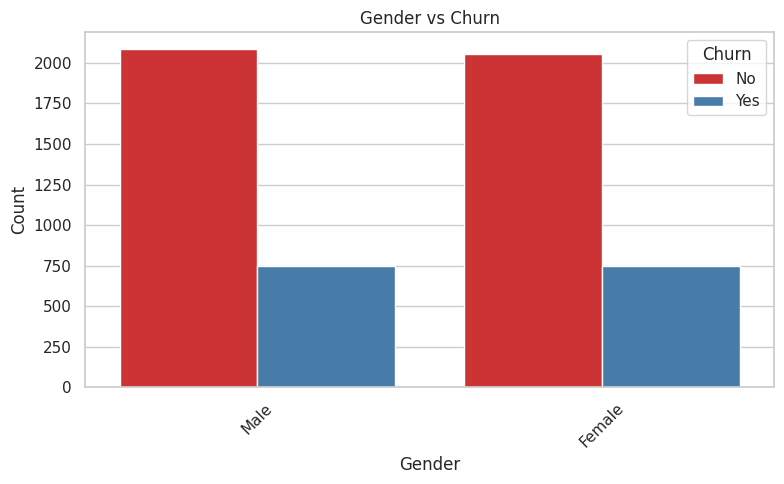

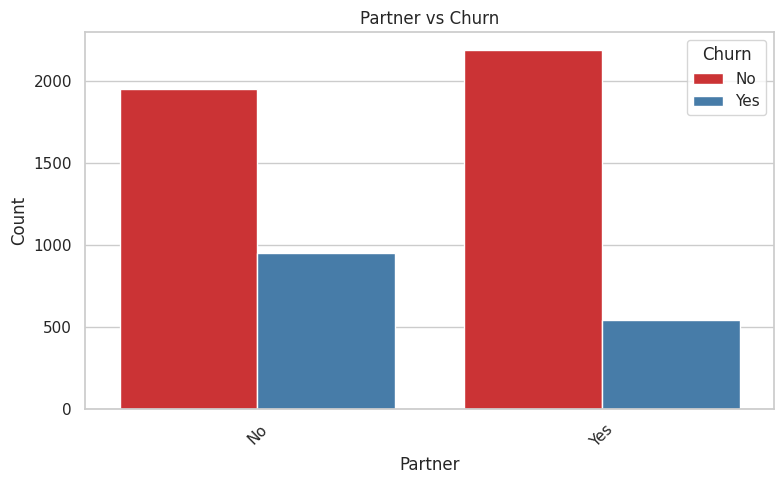

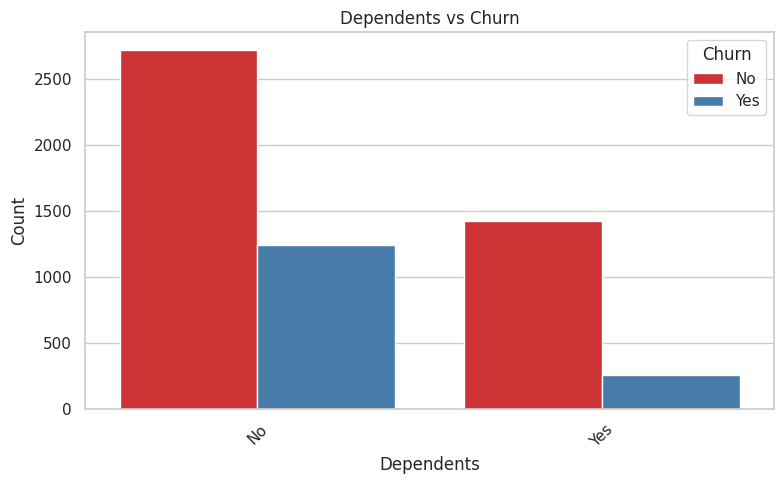

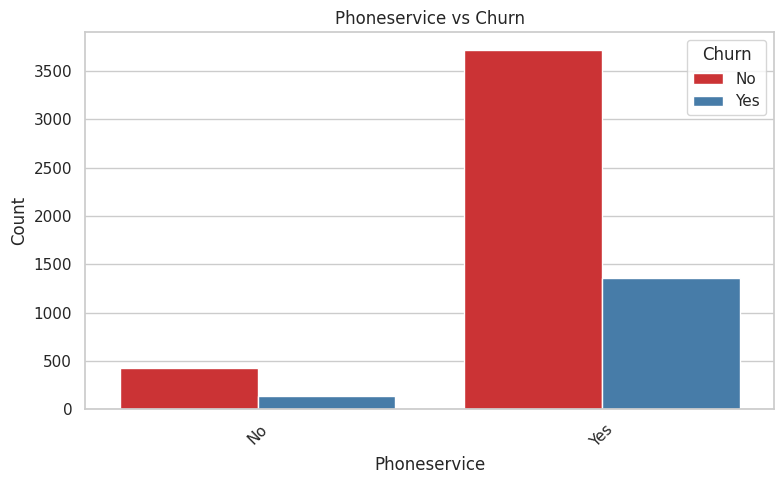

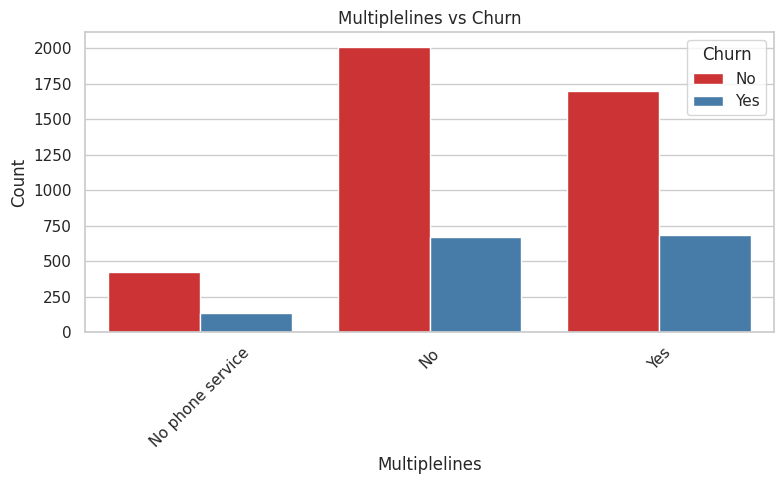

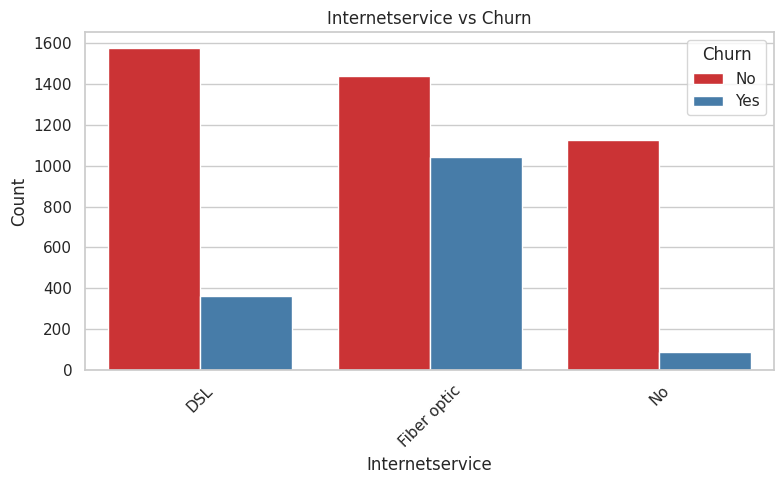

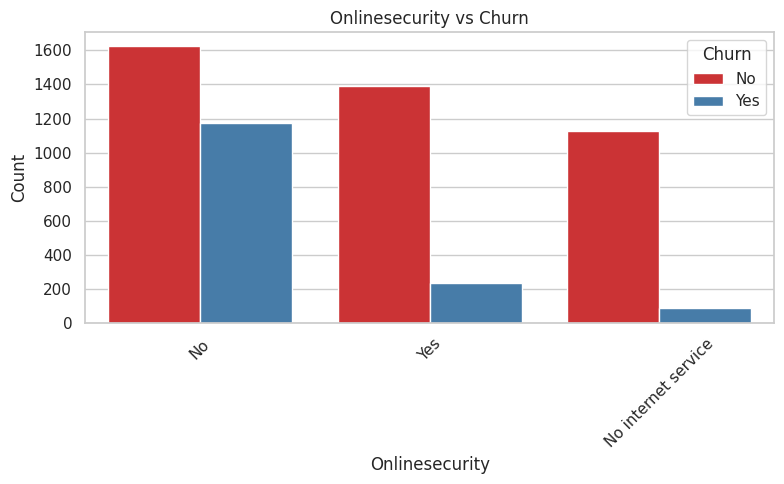

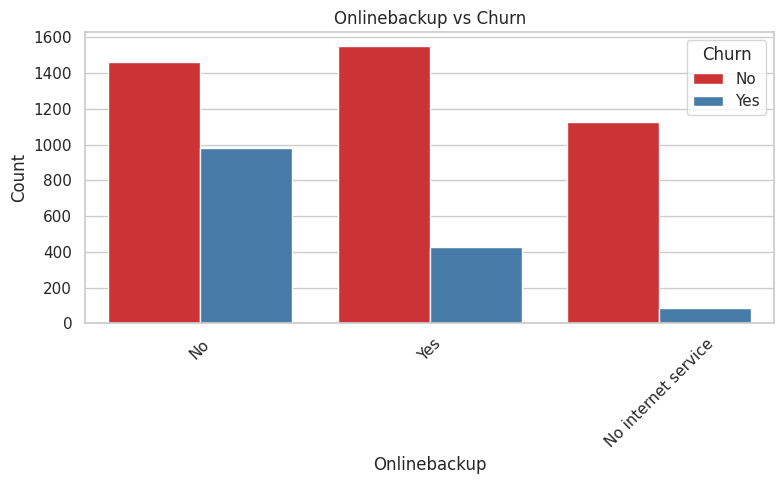

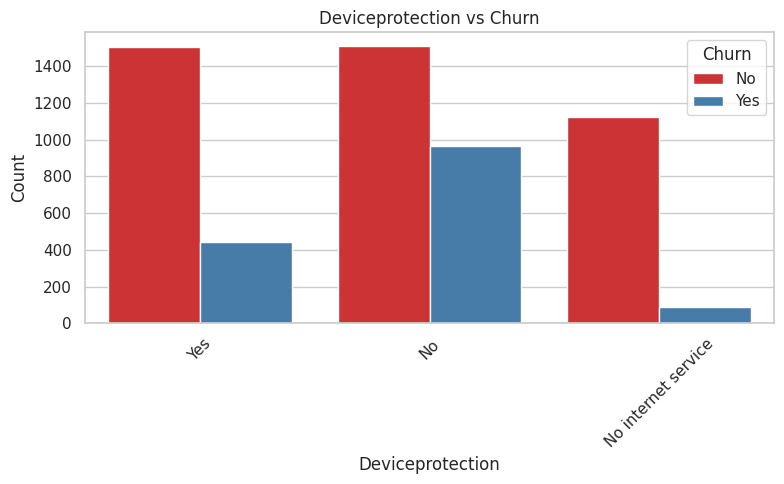

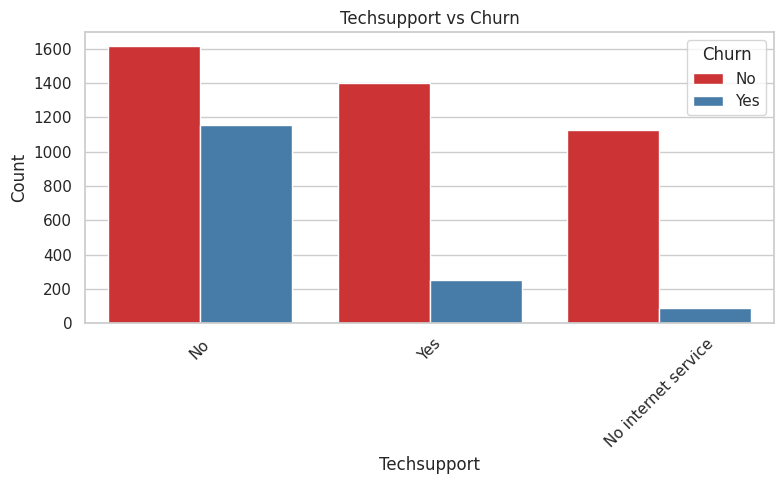

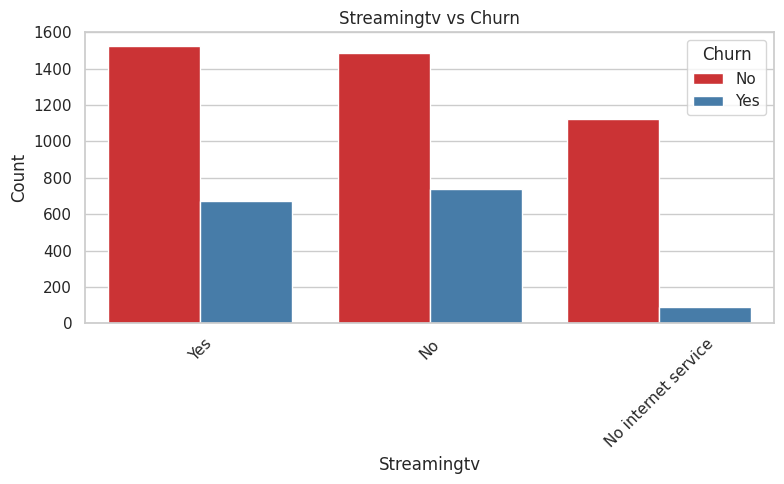

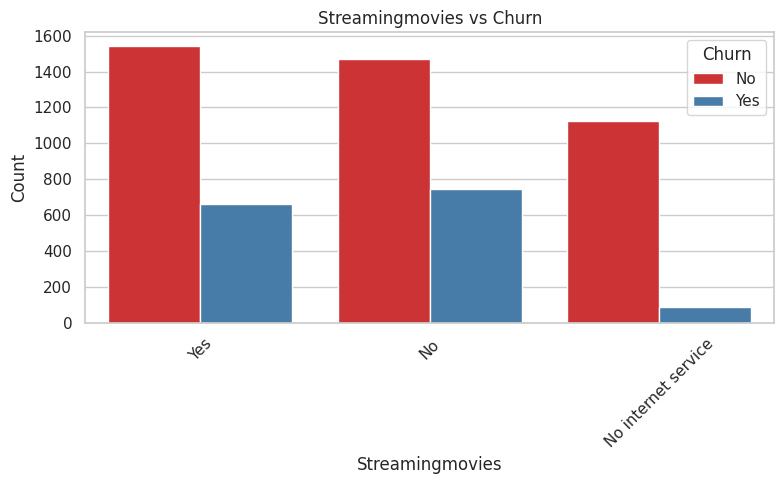

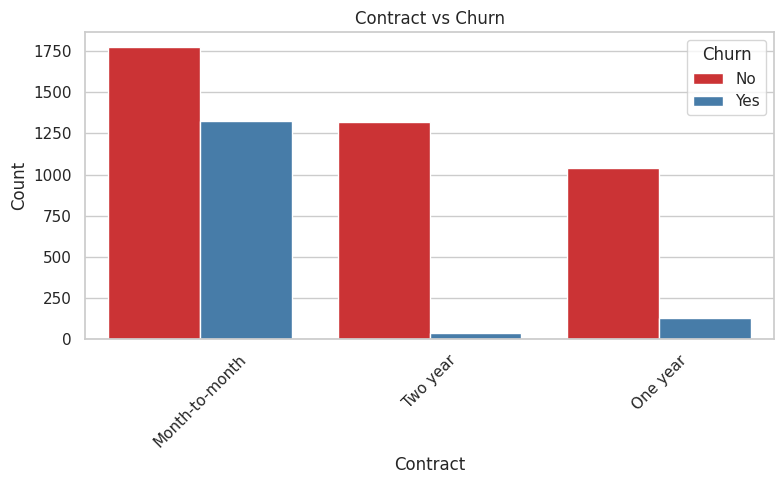

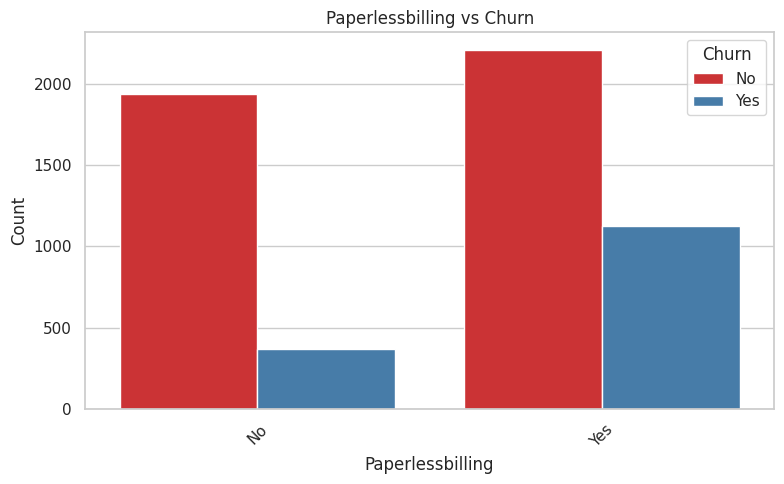

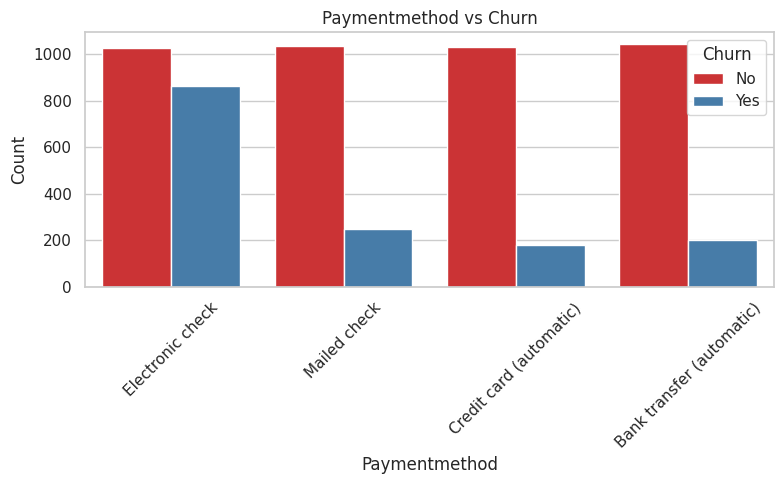

In [83]:
#variables categoricas a analizar
categorical_vars = ['gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod']
sns.set(style='whitegrid')
for var in categorical_vars:
  plt.figure(figsize=(8, 5))
  sns.countplot(x=var, hue='Churn', data=train_df, palette='Set1')
  plt.title(f'{var.capitalize()} vs Churn')
  plt.xlabel(var.capitalize()) #Corrected line
  plt.ylabel('Count')
  plt.legend(title='Churn', loc='upper right')
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show()

**Correlaciones**

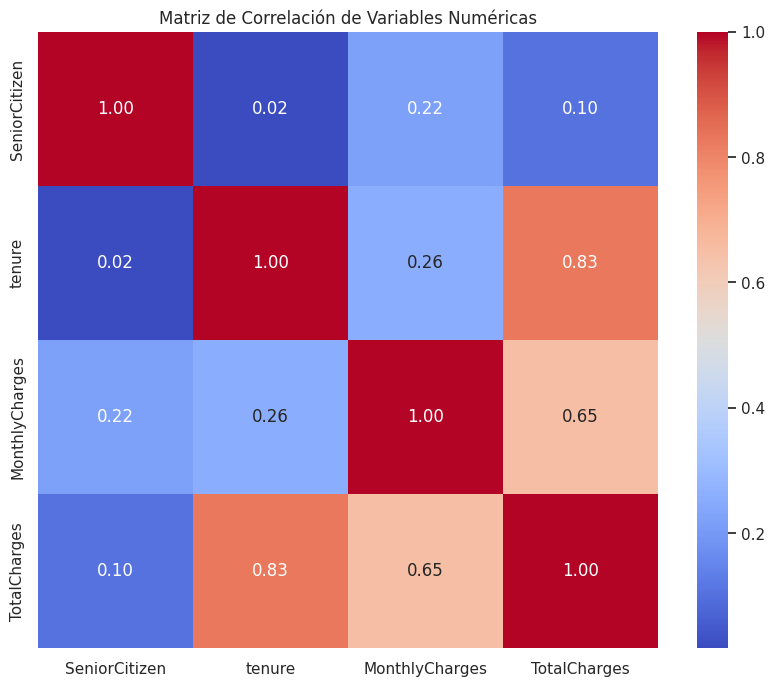

In [84]:
# Matriz de Correlación para variables numéricas
numeric_cols = train_df.select_dtypes(include=np.number).columns
correlation_matrix = train_df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

Permite tener una visión acerca de la correlación entre las variables numéricas. Una alternativa es realizar una conversión temporal de variables categóricas a numéricas para calcular las correlaciones.

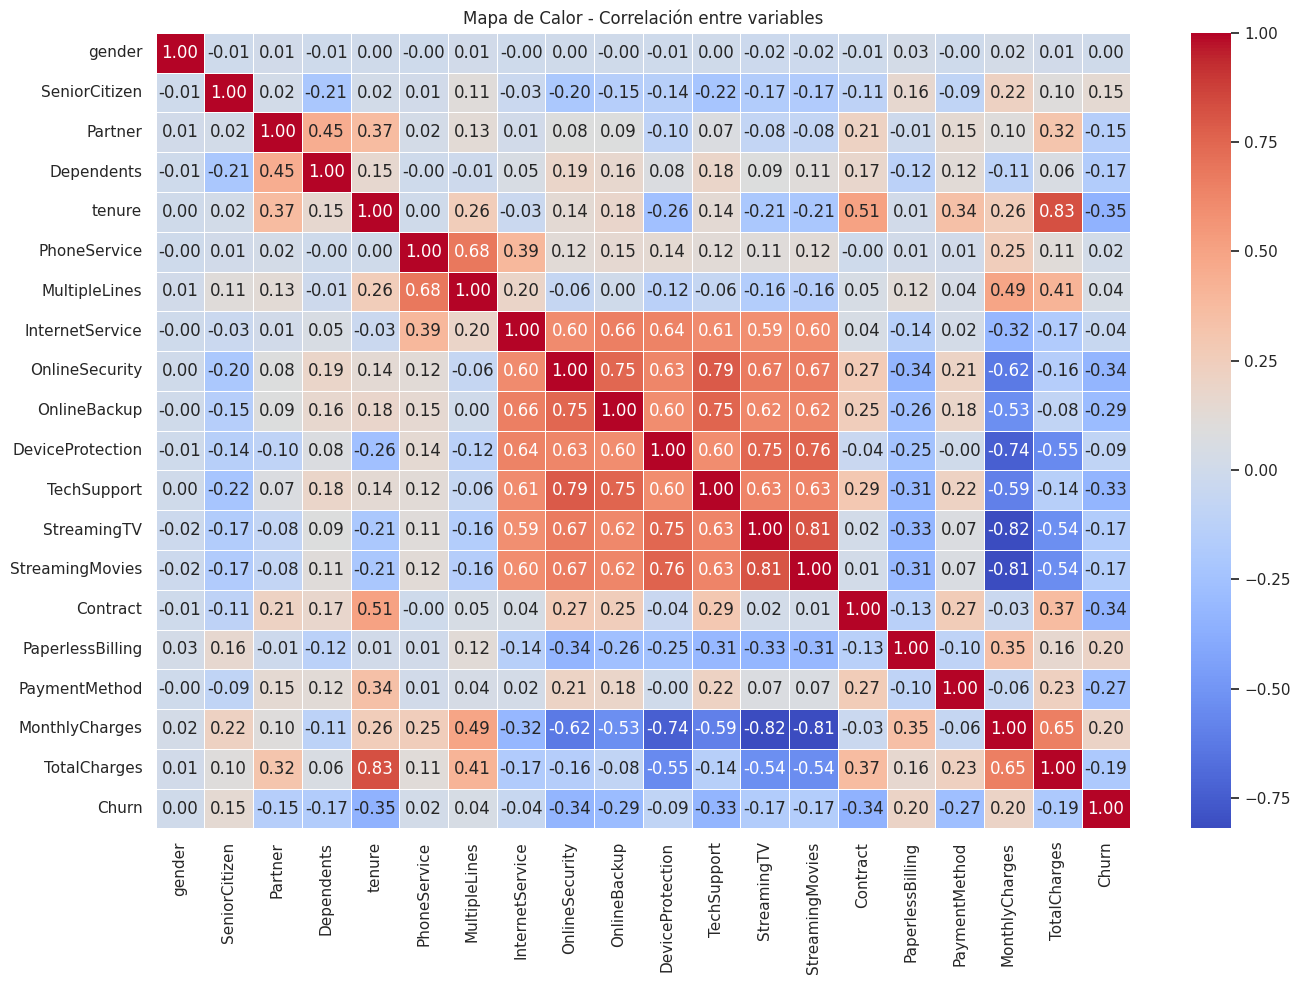

In [85]:
# Convertir variables categóricas a números temporales para poder calcular la correlación
df_corr = train_df.copy()

# Eliminar columnas que no aportan o no son numéricas
df_corr = df_corr.drop(['customerID'], axis=1)

# Convertir 'TotalCharges' a numérico (si es necesario)
df_corr['TotalCharges'] = pd.to_numeric(df_corr['TotalCharges'], errors='coerce')

# Convertir variables categóricas a valores numéricos
for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = pd.factorize(df_corr[col])[0]

# Calcular la matriz de correlación (Pearson o Spearman)
correlation_matrix = df_corr.corr(method='pearson')  # o 'spearman'

# Crear el mapa de calor
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor - Correlación entre variables")
plt.tight_layout()
plt.show()

Por lo que investigue al respecto, se deben tener la siguientes precauciones: pd.factorize() impone un orden arbitrario entre las categorías:

Ejemplo: "Yes" se convierte en 0, "No" en 1, pero esto no implica que haya una relación ordinal o métrica real entre ellos. Por eso, la interpretación del coeficiente de correlación puede ser engañosa para variables originalmente categóricas sin orden natural. Por lo tanto, no resulta adecuado para inferencias estadísticas serias, pero sí sirve como análisis exploratorio rápido para detectar relaciones que luego se pueden investigar más a fondo.


# Conclusiones obtenidas con el analisis EDA realizado con SWEETVIZ, complementado con el análisis propio.

**Distribución de la Variable Objetivo – Churn.**
Churn es una variable binaria.

Se evidencia un desbalance moderado:

-Clientes que no abandonan (Churn = 0): más frecuentes.

-Clientes que abandonan (Churn = 1): minoría, lo cual sugiere la necesidad de aplicar técnicas de balanceo de clases.

**Variables Numéricas Destacadas**
Resalta las variables con mayor diferencia de distribución entre Churn = 0 y Churn = 1.

-tenure: Clientes que permanecen (Churn = 0) tienen tenure (antigüedad) significativamente mayor. Indica que los clientes nuevos tienen más probabilidades de abandonar.

-MonthlyCharges: Clientes con mayor MonthlyCharges tienen mayor probabilidad de Churn = 1.Puede implicar que los servicios de mayor costo provocan abandono.

-TotalCharges: Altamente correlacionada con tenure y MonthlyCharges.
Clientes con altos TotalCharges tienden a no abandonar, posiblemente porque llevan más tiempo y tienen mayor compromiso.

**Variables Categóricas Relevantes**

Muestra cómo las categorías se distribuyen para Churn = 0 y Churn = 1. Algunas de las más influyentes:

-Contract: Contratos de tipo "Month-to-month" tienen alta incidencia de Churn.
Contratos "One year" o "Two year" retienen más clientes.

-InternetService: Clientes con servicio de "Fiber optic" tienen más churn.Clientes con "No internet service" tienen menos churn.

-PaymentMethod: Pagos con tarjetas electrónicas (Electronic check) tienen mayor churn. Métodos como transferencia bancaria o tarjeta de crédito muestran menor tasa de abandono.

**Conclusiones del EDA**

Variables altamente predictivas: Contract, tenure, MonthlyCharges, TotalCharges, InternetService. Preprocesamiento necesario:

Codificar categóricas (Se realiza más abajo).

Escalar numéricas si se usan modelos sensibles a escala (se hace más abajo).

Considerar reducción de dimensionalidad si se hace one-hot encoding. (se probó, y se obtuvo menor ROC AU).

Balanceo de clases necesario por el desbalance en Churn. (se probó con class_weight='balanced' y se obtuvo una perfomance menor).




# **3. Preprocesamiento de Datos**

## Se preparan los datos para que puedan ser utilizados por los modelos de Machine Learning.

In [86]:
#Valores faltantes
print("Porcentaje de valores faltantes por columna:")
print((train_df.isnull().sum() / len(train_df)) * 100)

Porcentaje de valores faltantes por columna:
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
Churn               0.0
dtype: float64


**No existen valores nulos.**

In [87]:
# ============================================
# 1. Eliminar columna no predictiva
# ============================================
df = train_df.copy()  # Trabajo sobre una copia
df.drop('customerID', axis=1, inplace=True)

In [88]:
df.shape # Chequear tamaño de Dataframe

(5634, 20)

In [89]:
df.info() # ver tipo de datos y valores de cada columna (campo)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5634 entries, 0 to 5633
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5634 non-null   object 
 1   SeniorCitizen     5634 non-null   int64  
 2   Partner           5634 non-null   object 
 3   Dependents        5634 non-null   object 
 4   tenure            5634 non-null   int64  
 5   PhoneService      5634 non-null   object 
 6   MultipleLines     5634 non-null   object 
 7   InternetService   5634 non-null   object 
 8   OnlineSecurity    5634 non-null   object 
 9   OnlineBackup      5634 non-null   object 
 10  DeviceProtection  5634 non-null   object 
 11  TechSupport       5634 non-null   object 
 12  StreamingTV       5634 non-null   object 
 13  StreamingMovies   5634 non-null   object 
 14  Contract          5634 non-null   object 
 15  PaperlessBilling  5634 non-null   object 
 16  PaymentMethod     5634 non-null   object 


In [90]:
# ============================================
# 2. Codificar variable objetivo 'Churn'
# ============================================
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

In [91]:
# ============================================
# Codificar variables categóricas
# ============================================
df_encoded = pd.get_dummies(df, drop_first=True)  # Evita multicolinealidad

In [92]:
df_encoded.shape ##Chequear tamaño de Dataframe despues de la codificación

(5634, 31)

In [93]:
df_encoded.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,5634.000000,5634.000000,5634.000000,5634.000000,5634.000000
mean,0.163294,32.485091,64.929961,2301.319027,0.265353
std,0.369667,24.568744,30.138105,2277.809211,0.441560
min,0.000000,0.000000,18.400000,18.850000,0.000000
25%,0.000000,9.000000,35.662500,408.850000,0.000000
50%,0.000000,29.000000,70.500000,1397.475000,0.000000
75%,0.000000,55.000000,90.000000,3835.825000,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [94]:
# ============================================
# 4. Separar variables predictoras y objetivo
# ============================================
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn'].values

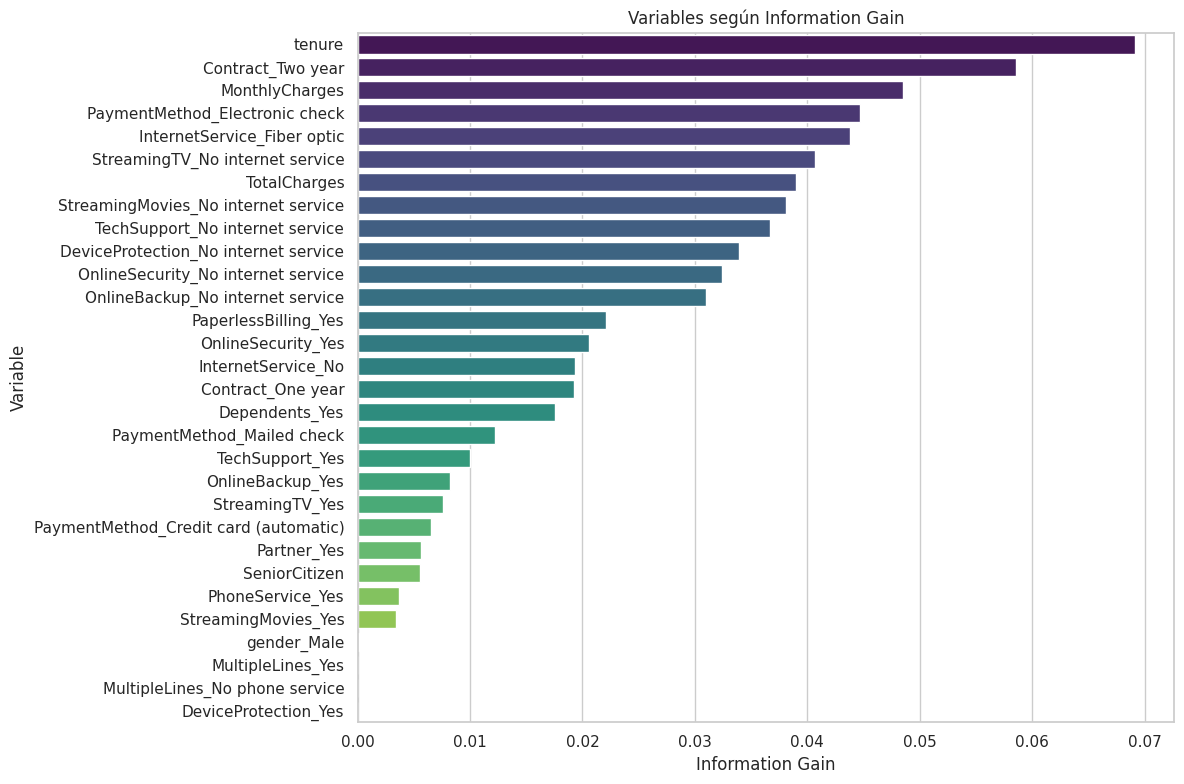

In [95]:
# ============================
# Aqui se muestra Information Gain que mide la relevancia individual de cada variable para predecir la variable objetivo (Churn).
# Se usa para selección de variables (feature selection).
# ============================
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x=mi_series.values[:35], y=mi_series.index[:35], palette="viridis")
plt.title("Variables según Information Gain")
plt.xlabel("Information Gain")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

In [96]:
# ============================================
# 5. Dividir en entrenamiento y prueba
# ============================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [97]:
# ============================================
# 6. Escalar variables numéricas
# ============================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **4. Modelado y Evaluación**

## Ahora se entrenan y evaluan los tres modelos requeridos:
## Regresión Logística, k-NN y Naive Bayes.


**REGRESIÓN LOGÍSTICA**

In [98]:
# ============================================
# 1. Modelo: Regresión logística
# ============================================
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [99]:
# ============================================
# 2. Predicción
# ============================================
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

In [100]:
# ============================================
# 3. Evaluación del modelo
# ============================================
print("Métricas del modelo:")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Métricas del modelo:
----------------------------------------
Accuracy: 0.8108
ROC AUC: 0.8494

Matriz de Confusión:
[[1131  135]
 [ 185  240]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.89      0.88      1266
           1       0.64      0.56      0.60       425

    accuracy                           0.81      1691
   macro avg       0.75      0.73      0.74      1691
weighted avg       0.80      0.81      0.81      1691



In [101]:
# ============================================
# 4. Visualización de algunas predicciones
# ============================================
results_df = pd.DataFrame({
    'Real': y_test,
    'Predicho': y_pred,
    'Probabilidad_Churn': np.round(y_pred_proba, 4)
})
print("\nEjemplos de predicciones:")
print(results_df.head(10))


Ejemplos de predicciones:
   Real  Predicho  Probabilidad_Churn
0     0         0              0.0430
1     0         0              0.1209
2     0         0              0.0532
3     0         0              0.1737
4     1         0              0.3919
5     0         0              0.2601
6     0         0              0.1760
7     0         0              0.4431
8     0         0              0.1348
9     0         0              0.1158


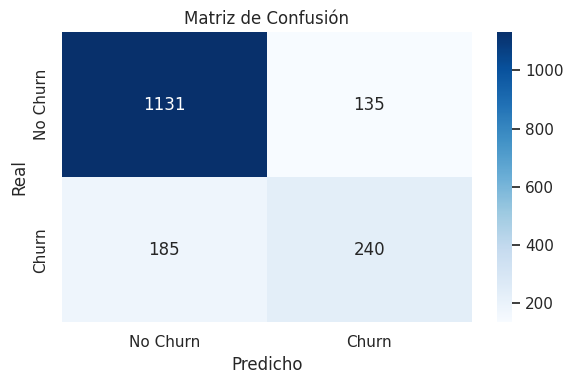

In [102]:
# ============================================
# 5. Matriz de confusión
# ============================================

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

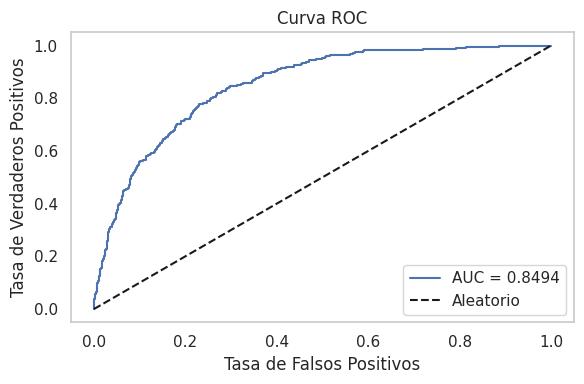


AUC (Área bajo la curva ROC): 0.8494


In [103]:
# ============================================
# 6. Curva ROC y AUC
# ============================================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--', label='Aleatorio')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.grid()
plt.tight_layout()
plt.show()

print(f"\nAUC (Área bajo la curva ROC): {auc_score:.4f}")

**KNN**

In [39]:
# 1. Importar librerías
#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
#from sklearn.neighbors import KNeighborsClassifier
#from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
#from sklearn.model_selection import cross_val_score
#from sklearn.metrics import roc_curve, auc

In [104]:
# ============================================
# 1. Validación cruzada
# ============================================
k_values = range(1, 100, 2) # Probar k de 1 a 99 (impares)
accuracies_cv = []

for k_val in k_values:
    knn = KNeighborsClassifier(n_neighbors=k_val)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    accuracies_cv.append(scores.mean()) # Guardar la media de las puntuaciones de CV

# Ahora comparas las accuracies_cv para encontrar el mejor k
best_k_cv = k_values[np.argmax(accuracies_cv)]
print(f"Mejor k (con CV en el conjunto de entrenamiento): {best_k_cv}")

Mejor k (con CV en el conjunto de entrenamiento): 75


Precisión con k = 1: 0.7238
Precisión con k = 3: 0.7569
Precisión con k = 5: 0.7806
Precisión con k = 7: 0.7747
Precisión con k = 9: 0.7907
Precisión con k = 11: 0.7930
Precisión con k = 13: 0.7936
Precisión con k = 15: 0.7924
Precisión con k = 17: 0.7942
Precisión con k = 19: 0.7948
Precisión con k = 21: 0.7901
Precisión con k = 23: 0.7972
Precisión con k = 25: 0.7954
Precisión con k = 27: 0.7972
Precisión con k = 29: 0.7930
Precisión con k = 31: 0.7954
Precisión con k = 33: 0.7972
Precisión con k = 35: 0.7966
Precisión con k = 37: 0.7978
Precisión con k = 39: 0.8031
Precisión con k = 41: 0.8054
Precisión con k = 43: 0.8054
Precisión con k = 45: 0.8001
Precisión con k = 47: 0.8013
Precisión con k = 51: 0.7978
Precisión con k = 53: 0.7972
Precisión con k = 55: 0.8025
Precisión con k = 57: 0.8048
Precisión con k = 59: 0.8031
Precisión con k = 61: 0.8031
Precisión con k = 63: 0.8054
Precisión con k = 65: 0.7989
Precisión con k = 67: 0.8019
Precisión con k = 69: 0.8037
Precisión con k = 7

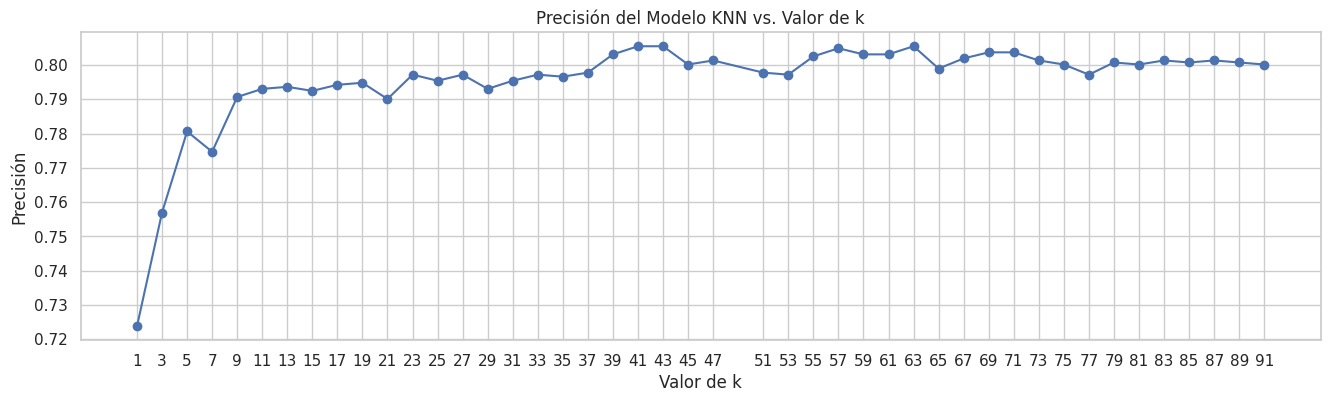

In [105]:
# Probar con diferentes valores de k
k_values = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31, 33, 35, 37, 39, 41, 43, 45, 47, 51, 53, 55, 57, 59, 61, 63, 65, 67, 69, 71, 73, 75, 77, 79, 81, 83, 85, 87, 89, 91]
accuracies = []

for k_val in k_values:
    knn = KNeighborsClassifier(n_neighbors=k_val)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred_k)
    accuracies.append(accuracy)
    print(f"Precisión con k = {k_val}: {accuracy:.4f}")

# Graficar los resultados
plt.figure(figsize=(16, 4))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b')
plt.title('Precisión del Modelo KNN vs. Valor de k')
plt.xlabel('Valor de k')
plt.ylabel('Precisión')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [106]:
# ============================================
# 2. Entrenar modelo KNN con el mejor k
# ============================================
# Con Validación Cruzada el mejor K = 75; pero probando con diferentes valores obtengo 41; por lo tanto entreno con 41 dado que obtengo mejor precisión.
knn = KNeighborsClassifier(n_neighbors=41)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=41)

In [107]:
# ============================================
# 3. Realizar predicciones
# ============================================
y_pred = knn.predict(X_test_scaled)
y_pred_proba = knn.predict_proba(X_test_scaled)[:, 1]

In [108]:
# ============================================
# 4. Evaluar el modelo
# ============================================
print("Métricas del modelo KNN:")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Métricas del modelo KNN:
----------------------------------------
Accuracy: 0.8054
ROC AUC: 0.8340

Matriz de Confusión:
[[1114  152]
 [ 177  248]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      1266
           1       0.62      0.58      0.60       425

    accuracy                           0.81      1691
   macro avg       0.74      0.73      0.74      1691
weighted avg       0.80      0.81      0.80      1691



In [109]:
# ============================================
# 5. Visualizar algunas predicciones
# ============================================
results_df = pd.DataFrame({
    'Real': y_test,
    'Predicho': y_pred,
    'Probabilidad_Churn': np.round(y_pred_proba, 4)
})
print("\nEjemplos de predicciones:")
print(results_df.head(10))


Ejemplos de predicciones:
   Real  Predicho  Probabilidad_Churn
0     0         0              0.1220
1     0         0              0.2195
2     0         0              0.0976
3     0         0              0.2439
4     1         0              0.3659
5     0         0              0.1707
6     0         0              0.4634
7     0         1              0.5122
8     0         0              0.0732
9     0         0              0.1707


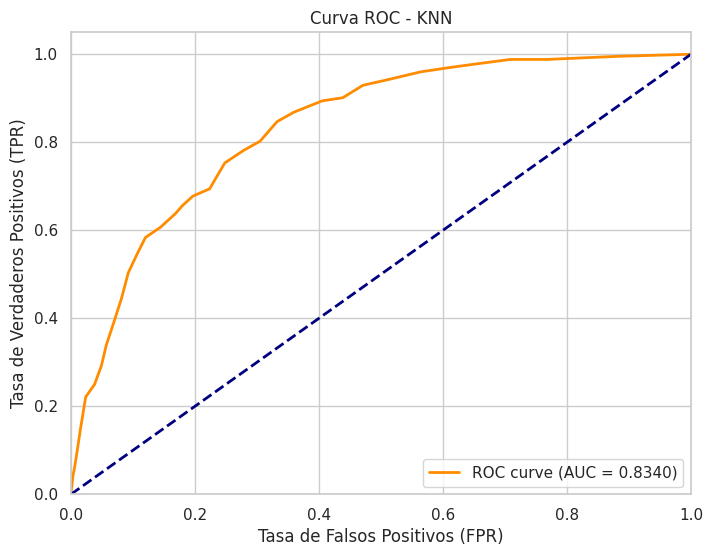

In [110]:
# ============================================
# 6. Curva ROC y AUC
# ============================================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - KNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**NAIVE BAYES**

In [47]:
# 1. Importar librerías
#import pandas as pd
#import numpy as np
#import matplotlib.pyplot as plt
#from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import StandardScaler
#from sklearn.naive_bayes import GaussianNB
#from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
#from sklearn.metrics import roc_curve, auc

In [111]:
# ============================================
# 1. Entrenar modelo Naive Bayes
# ============================================
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

GaussianNB()

In [112]:
# ============================================
# 2. Realizar predicciones
# ============================================
y_pred = gnb.predict(X_test_scaled)
y_pred_proba = gnb.predict_proba(X_test_scaled)[:, 1]

In [113]:
# ============================================
# 3. Evaluar el modelo
# ============================================
print("Métricas del modelo Naive Bayes:")
print("-" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Métricas del modelo Naive Bayes:
----------------------------------------
Accuracy: 0.6617
ROC AUC: 0.8198

Matriz de Confusión:
[[743 523]
 [ 49 376]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.94      0.59      0.72      1266
           1       0.42      0.88      0.57       425

    accuracy                           0.66      1691
   macro avg       0.68      0.74      0.65      1691
weighted avg       0.81      0.66      0.68      1691



In [114]:
# ============================================
# 4. Visualizar algunas predicciones
# ============================================
results_df = pd.DataFrame({
    'Real': y_test,
    'Predicho': y_pred,
    'Probabilidad_Churn': np.round(y_pred_proba, 4)
})
print("\nEjemplos de predicciones:")
print(results_df.head(10))


Ejemplos de predicciones:
   Real  Predicho  Probabilidad_Churn
0     0         0              0.0000
1     0         0              0.3985
2     0         0              0.0000
3     0         1              0.9786
4     1         1              0.9973
5     0         0              0.4105
6     0         1              0.9636
7     0         1              0.9984
8     0         0              0.0000
9     0         1              0.8038


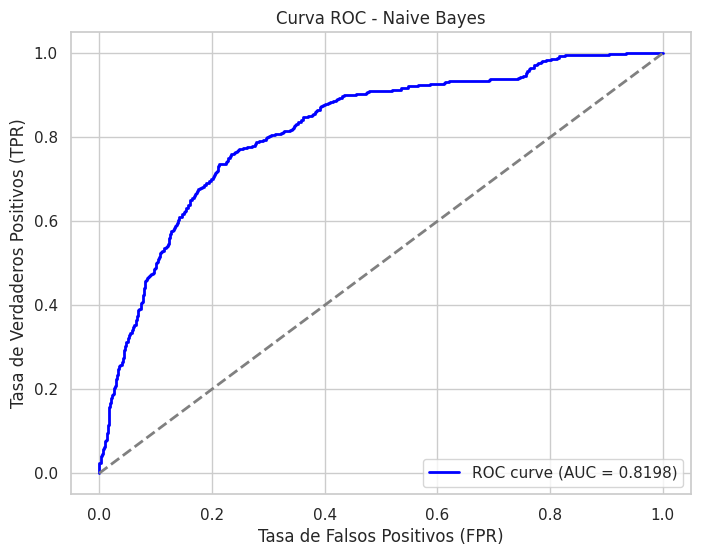

In [115]:
# ============================================
# 5. Curva ROC y AUC
# ============================================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Naive Bayes')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

#  **5. Selección de Modelo y Generación de Sumisión para Kaggle**

## Basado en los resultados de validación, se elige el mejor modelo . Luego, se re-entrena usando **todos los datos de `train.csv`** y se usa para hacer predicciones sobre `test.csv`.


**Preparar el archivo a probar con los datos entrenados**

In [116]:
#test_df = pd.read_csv('test.csv')
#sample_submission_df = pd.read_csv('sample_submission.csv')
# ============================================
# 1. Eliminar columna customer
# ============================================
df1 = test_df.copy()  # Trabajo sobre una copia
# Obtener customerID
customer_ids = df1['customerID']

In [117]:
df1.shape

(1409, 20)

In [118]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        1409 non-null   object 
 1   gender            1409 non-null   object 
 2   SeniorCitizen     1409 non-null   int64  
 3   Partner           1409 non-null   object 
 4   Dependents        1409 non-null   object 
 5   tenure            1409 non-null   int64  
 6   PhoneService      1409 non-null   object 
 7   MultipleLines     1409 non-null   object 
 8   InternetService   1409 non-null   object 
 9   OnlineSecurity    1409 non-null   object 
 10  OnlineBackup      1409 non-null   object 
 11  DeviceProtection  1409 non-null   object 
 12  TechSupport       1409 non-null   object 
 13  StreamingTV       1409 non-null   object 
 14  StreamingMovies   1409 non-null   object 
 15  Contract          1409 non-null   object 
 16  PaperlessBilling  1409 non-null   object 


In [119]:
df1.drop('customerID', axis=1, inplace=True)

In [120]:
df1.shape

(1409, 19)

In [121]:
# ============================================
# 2. Codificar variables categóricas
# ============================================
df1_encoded = pd.get_dummies(df1, drop_first=True)  # Evita multicolinealidad

In [122]:
df1_encoded.shape

(1409, 30)

In [123]:
df1_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1409 entries, 0 to 1408
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          1409 non-null   int64  
 1   tenure                                 1409 non-null   int64  
 2   MonthlyCharges                         1409 non-null   float64
 3   TotalCharges                           1409 non-null   float64
 4   gender_Male                            1409 non-null   bool   
 5   Partner_Yes                            1409 non-null   bool   
 6   Dependents_Yes                         1409 non-null   bool   
 7   PhoneService_Yes                       1409 non-null   bool   
 8   MultipleLines_No phone service         1409 non-null   bool   
 9   MultipleLines_Yes                      1409 non-null   bool   
 10  InternetService_Fiber optic            1409 non-null   bool   
 11  Inte

In [124]:
# ============================================
# 3. Escalar variables numéricas
# ============================================
X_prueba_scaled = scaler.transform(df1_encoded)

# **Función para generar el archivo de sumisión**

**Variables de la funcion**

In [125]:
X_train_full = X_train_scaled
y_train_full = y_train
X_test_full = X_prueba_scaled

In [126]:
def generar_submission_file(final_model, X_train_full, y_train_full, X_test_full, customer_ids, filename="submission.csv"):
    """
    Entrena el modelo final con todos los datos de entrenamiento, genera predicciones
    de probabilidad en el conjunto de prueba y guarda el archivo de sumisión.

    Args:
        final_model: El modelo y preprocesamiento elegido.
        X_train_full (DataFrame): El DataFrame completo de características de entrenamiento.
        y_train_full (Series): La Serie completa del objetivo de entrenamiento.
        X_test_full (DataFrame): El DataFrame de características de prueba.
        customer_ids (Series): La Serie de customerID para el archivo de sumisión.
        filename (str): El nombre del archivo CSV de salida.
    """
    print("Entrenando el modelo final con todos los datos de entrenamiento...")
    final_model.fit(X_train_full, y_train_full)
    print("Modelo final entrenado.")

    print("Generando predicciones de probabilidad sobre el conjunto de prueba...")
    test_probabilities = final_model.predict_proba(X_test_full)[:, 1]

    print(f"Creando el archivo de sumisión '{filename}'...")
    submission_df = pd.DataFrame({
        'customerID': customer_ids,
        'Churn': test_probabilities
    })

    submission_df.to_csv(filename, index=False)

    print(f"Archivo '{filename}' generado exitosamente.")
    print("Primeras 5 filas del archivo de sumisión:")
    display(submission_df.head())
    return submission_df

In [127]:
mejor_modelo = log_reg

In [128]:
submission_final = generar_submission_file(
    final_model=mejor_modelo,
    X_train_full=X_train_scaled,
    y_train_full=y_train,
    X_test_full=X_prueba_scaled,
    customer_ids=customer_ids,
    filename="mi_submission_final.csv"
)

Entrenando el modelo final con todos los datos de entrenamiento...
Modelo final entrenado.
Generando predicciones de probabilidad sobre el conjunto de prueba...
Creando el archivo de sumisión 'mi_submission_final.csv'...
Archivo 'mi_submission_final.csv' generado exitosamente.
Primeras 5 filas del archivo de sumisión:


,customerID,Churn
0,4376-KFVRS,0.040981
1,2754-SDJRD,0.678918
2,9917-KWRBE,0.077291
3,0365-GXEZS,0.394046
4,9385-NXKDA,0.022597


#  **6. Conclusiones**

**¿Qué modelo funcionó mejor?**

Por las características del Dataset referido a un problema binario (Churn = 0 o 1), con muchas variables categóricas transformadas a dummies y algunas variables numéricas como tenure, MonthlyCharges, entiendo que es ideal para la regresión logística, ya que es un modelo lineal robusto y especialmente diseñado para clasificación binaria.
Por no ser muy grande el conjunto de datos y al ser el modelo de Regresión Logística adecuado para el manejo de las variables categóricas codificadas, pudo compensar el balance de clases.
Además, no se ve afectada por la dimensionalidad como KNN, ni depende de supuestos tan estrictos como Naive Bayes.
En este caso las  variables predictoras están relacionadas linealmente con la probabilidad de Churn (lo cual es frecuente en variables como MonthlyCharges, tenure, Contract, etc.), entonces este modelo es el adecuado para abordar la problematica de la clasificación binaria.

**¿Cuáles fueron las características más importantes o los descubrimientos más interesantes del EDA?**

-Que la variable objetivo (Churn) presenta una Distribución desbalanceada, aproximadamente el 27% de los clientes pertenecen a la clase “Churn = 1” (clientes que abandonaron), lo cual indica que se debería incorporar técnicas de balanceo.

-MonthlyCharges: Clientes que pagan más mensualmente tienden a tener más probabilidad de Churn, o sea Distribución más alta en la clase Churn = 1.

tenure: es una de las variables con mejor predicción. Los clientes que llevan más tiempo en la empresa (alta tenure) tienden a no abandonar. Y al reves, un tenure bajo, Churn alto.

-Confirmación de patrones conocidos: Clientes nuevos (baja tenure) y con contratos poco comprometidos (mensuales) son los más propensos a irse. Los servicios adicionales como tech support y seguridad online son protectores contra la pérdida de clientes.

En terminos generales, puede decirse que al conocer la naturaleza de los datos (tipos de variables), poder predictivo, correlación, nos dió un panorama claro de la información contenida en el Dataset, y asi tener una guía para abordar el análisis del problema de resolver.

**¿Qué desafíos encontraron y cómo los resolvieron?**

Si bien los datos presentan un desbalanceo moderado, al incorporar estas técnicas, la perfomance ontenida fue menor, por lo tanto no se incluyó esa técnica.

Una semilla de 100 fue la ideal, dió un mejor rendimiento, pero al subir a Kaggle, se obtuvo un menor score.

En KNN, con validación cruzada se obtuvo el mejor K = 75. Luego al probar con diferentes valores, dió que el mejor K = 41. Por lo tanto se optó por este.

Entiendo que esto es un proceso, en el cual a partir de la investigación, prueba y error, permite adquirir las competencias y exporiencia necesarias para abordar los problemas a resolver.

**En la entrega se adjunta: Plantilla Jupyter Notebook - Archivo de sumissión - Reporte en Sweetvif.**

**FIN**